# Notebook 02 — Event Definition & Detection
**Thesis:** Chapter 6 | **Input:** `data/1_reconstructed.csv` | **Output:** `data/2_events.csv`

---

## Purpose
Adds 18 event indicator columns to the reconstructed dataset.

An **event** is a binary or categorical condition at the time of each received packet.  
Example: "Was CO₂ above 700 ppm at this moment?"

| Family | Events | Why it matters |
|--------|--------|---------------|
| Occupancy (CO₂) | E1, E2 | CO₂ is the best non-invasive proxy for human presence |
| Temporal | E3, E4, E5, E6 | Office activity follows predictable daily and weekly cycles |
| Air Quality (PM2.5) | E7, E8 | PM2.5 spikes mark activity bursts — cleaning, printing, cooking |
| Atmospheric | E9, E10, E11, E12 | Pressure, humidity, temperature vary seasonally with HVAC |
| TX Config | E13, E14, E15 | SF controls Time-on-Air and therefore collision probability |
| Burst Loss | E16 | Classifies loss episodes by severity |
| Signal Context | E17, E18 | RSSI/ESP of last received packet — proxy for channel state |

Events are added to the full dataset.  
Notebook 03 filters to `PDR_link` intervals (excluding outages and SF artifacts) before correlating.

## 0 · Imports & Load

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '1_reconstructed.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6}
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf'); fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: {name}')
    plt.show()

print('Figure style loaded.')

Figure style loaded.


## 1 · Occupancy Events — CO₂  *(§6.1)*

CO₂ rises linearly with the number of people present — human metabolism produces ~200 ml CO₂/min at rest.  
Outdoor ambient is ~420 ppm. Weekday mean in this building is ~576 ppm vs ~457 ppm on weekends,  
confirming CO₂ as a reliable occupancy proxy.

| Event | Definition |
|-------|-----------|
| E1 | CO₂ tier: background (<500) / moderate (500–700) / high (>700 ppm) |
| E2 | CO₂ rising: delta > 20 ppm per 60s — occupancy actively increasing |

In [3]:
# E1: CO2 tier — 500 ppm = outdoor ambient ceiling, 700 ppm = moderate occupancy onset
df['e1_co2_tier'] = pd.cut(
    df['co2'],
    bins=[0, 500, 700, 10_000],
    labels=['background', 'moderate', 'high']
)

# E2: CO2 rising — delta > 20 ppm/60s signals people arriving
# 20 ppm chosen to exceed BME280 sensor noise (~±10 ppm)
# computed per device to avoid cross-device boundary artifacts
df['e2_co2_rising'] = (
        df.groupby('device_id')['co2'].diff() > 20
).astype(int)

print('CO2 tier distribution (E1):')
print(df['e1_co2_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(
    f'\nCO2 rising intervals (E2): {df["e2_co2_rising"].sum():,}  ({df["e2_co2_rising"].mean() * 100:.1f}% of all intervals)')
print(f'CO2 mean overall         : {df["co2"].mean():.0f} ppm  |  std: {df["co2"].std():.0f} ppm')

CO2 tier distribution (E1):
e1_co2_tier
background    63.4%
moderate      28.2%
high           8.4%

CO2 rising intervals (E2): 2,541  (0.1% of all intervals)
CO2 mean overall         : 516 ppm  |  std: 117 ppm


  Saved: 02_a_co2_distribution


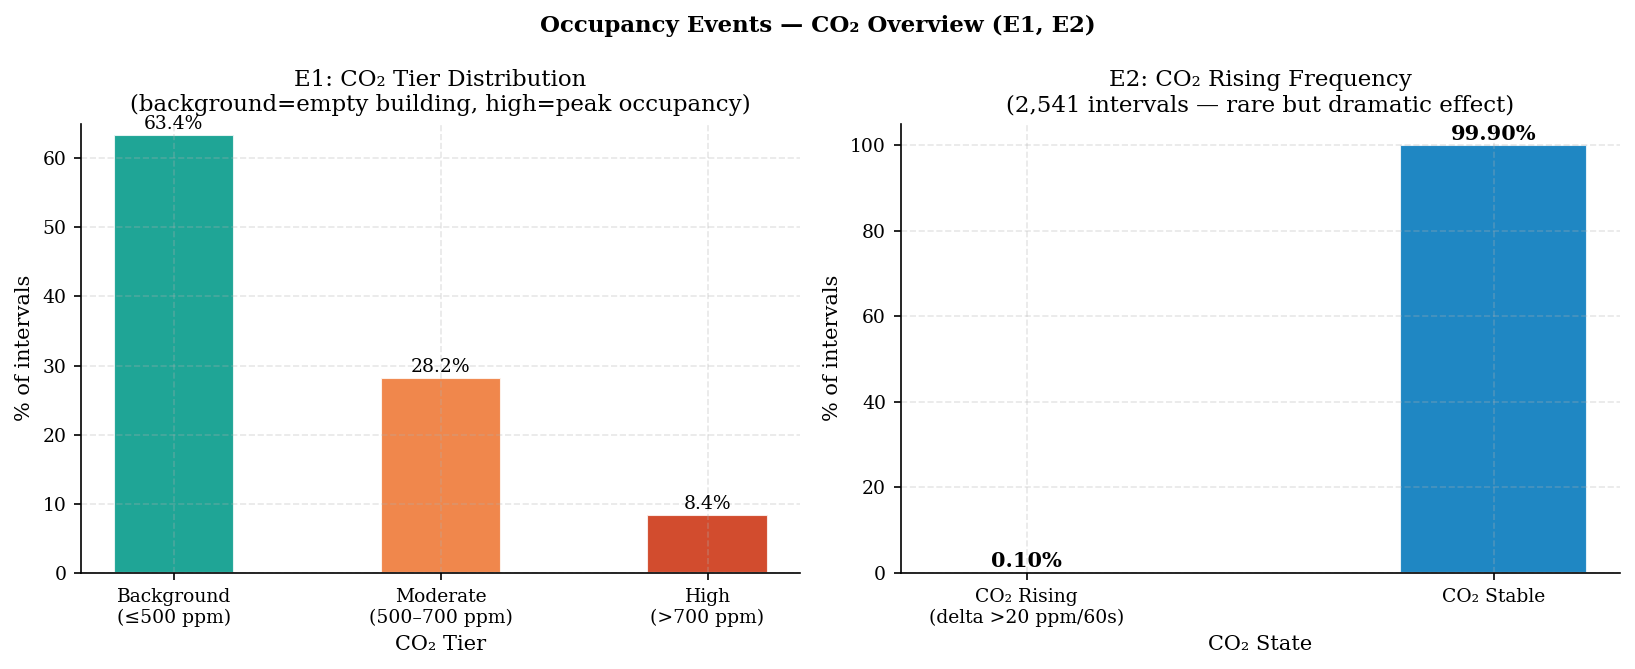

In [4]:
# Fig 02-A — CO₂ Tier Distribution (E1) + CO₂ Rising Rate (E2)
tiers  = ['background','moderate','high']
xlabs  = ['Background\n(≤500 ppm)','Moderate\n(500–700 ppm)','High\n(>700 ppm)']
pcts   = df['e1_co2_tier'].value_counts(normalize=True).reindex(tiers).fillna(0)*100
rising_rate = df['e2_co2_rising'].mean()*100
stable_rate = 100 - rising_rate

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left: E1 CO2 tier distribution
bars = axes[0].bar(xlabs, pcts.values, color=[C['green'],C['orange'],C['red']],
                    width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('CO\u2082 Tier')
axes[0].set_ylim(0, 65)
axes[0].set_title('E1: CO\u2082 Tier Distribution\n(background=empty building, high=peak occupancy)')

# right: E2 CO2 rising vs stable
bars2 = axes[1].bar(['CO\u2082 Rising\n(delta >20 ppm/60s)','CO\u2082 Stable'],
                     [rising_rate, stable_rate],
                     color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for bar, v in zip(bars2, [rising_rate, stable_rate]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('CO\u2082 State')
axes[1].set_ylim(0, 105)
axes[1].set_title(f'E2: CO\u2082 Rising Frequency\n'
                   f'({df["e2_co2_rising"].sum():,} intervals — rare but dramatic effect)')

fig.suptitle('Occupancy Events — CO\u2082 Overview (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_a_co2_distribution')

## 2 · Temporal Events  *(§6.2)*

Converted to `Europe/Berlin` local time — handles both DST transitions  
(October 2024 and March 2025) automatically.

| Event | Definition |
|-------|-----------|
| E3 | Weekday (1) vs weekend (0) — coarsest occupancy signal |
| E4 | Time-of-day band: night / morning / peak / evening |
| E5 | Office hours — weekday AND 08:00–17:59 |
| E6 | Season — autumn / winter / spring across 34-week campaign |

In [5]:
# local time — required for correct hour/weekday extraction across DST boundaries
local = df['time'].dt.tz_convert('Europe/Berlin')
df['hour'] = local.dt.hour
df['dayofweek'] = local.dt.dayofweek  # 0=Monday, 6=Sunday
df['month'] = local.dt.month

# E3: weekday vs weekend
df['e3_is_weekday'] = (df['dayofweek'] < 5).astype(int)

# E4: time-of-day bands — shift hours so night starts at 0: hour 22 → 0, hour 23 → 1, etc.
shifted_hour = (df['hour'] - 22) % 24

df['e4_time_of_day'] = pd.cut(
    shifted_hour,
    bins=[-1, 5, 11, 17, 23],
    labels=['night', 'morning', 'peak', 'evening']
)

# E5: office hours — weekday AND 08:00–17:59
df['e5_office_hours'] = (
        (df['e3_is_weekday'] == 1) & df['hour'].between(8, 17)
).astype(int)

# E6: season — campaign spans autumn 2024, winter 2024/25, spring 2025
df['e6_season'] = df['month'].map({
    9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring'
})

print(
    f'Weekday share (E3)   : {df["e3_is_weekday"].mean() * 100:.1f}%  |  Weekend: {(1 - df["e3_is_weekday"].mean()) * 100:.1f}%')

tod = df['e4_time_of_day'].value_counts(normalize=True).mul(100).round(1)
print(
    f'Time-of-day (E4)     : night={tod.get("night", 0):.1f}%  morning={tod.get("morning", 0):.1f}%  peak={tod.get("peak", 0):.1f}%  evening={tod.get("evening", 0):.1f}%')
print('''
22:00–03:59  → empty, everyone gone home, cleaners maybe
04:00–09:59  → people arriving, building warming up
10:00–15:59  → full occupancy, peak activity
16:00–21:59  → people leaving, evening wind-down
''')
print(f'Office hours (E5)    : {df["e5_office_hours"].mean() * 100:.1f}%')
print(f'Season counts (E6)   : {df["e6_season"].value_counts().to_dict()}')

Weekday share (E3)   : 70.7%  |  Weekend: 29.3%
Time-of-day (E4)     : night=25.2%  morning=25.0%  peak=24.8%  evening=25.0%

22:00–03:59  → empty, everyone gone home, cleaners maybe
04:00–09:59  → people arriving, building warming up
10:00–15:59  → full occupancy, peak activity
16:00–21:59  → people leaving, evening wind-down

Office hours (E5)    : 29.2%
Season counts (E6)   : {'autumn': 703823, 'spring': 688573, 'winter': 593629}


  Saved: 02_b_temporal_distributions


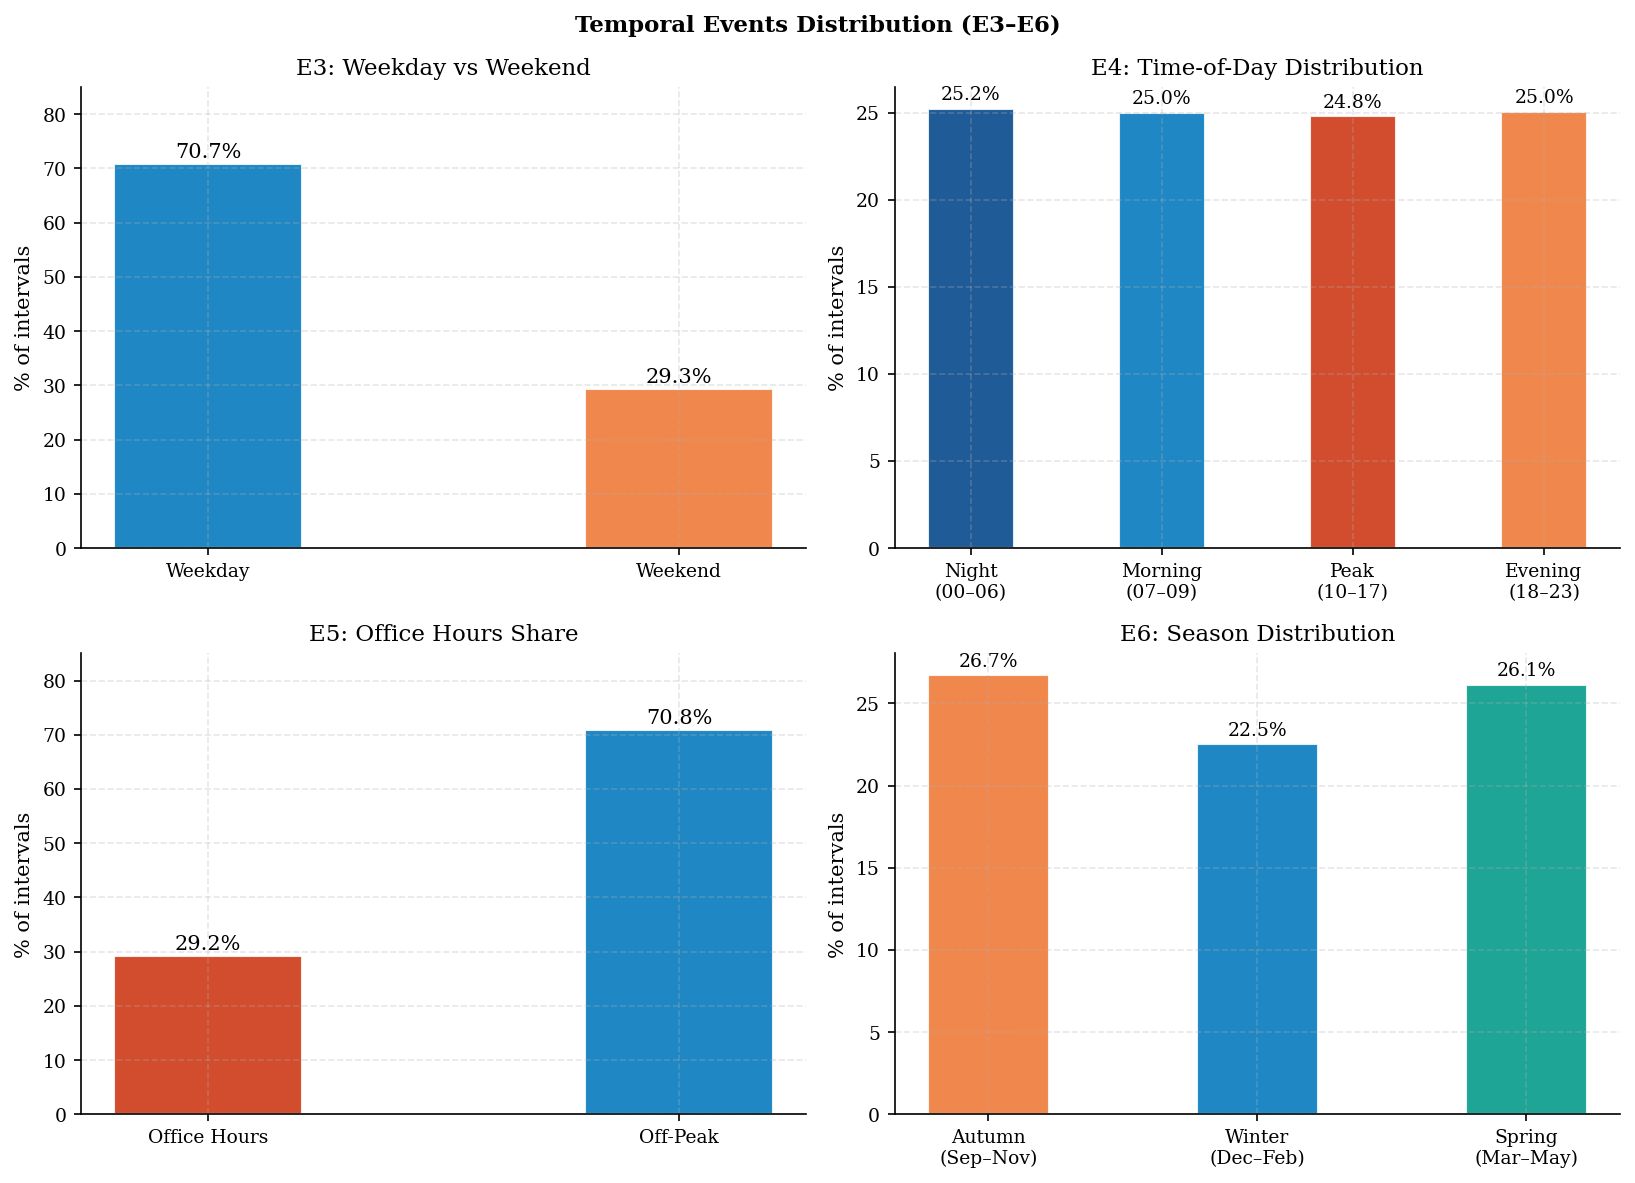

In [6]:
# Fig 02-B — Temporal Event Distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
wk = df['e3_is_weekday'].mean()*100
axes[0,0].bar(['Weekday','Weekend'],[wk,100-wk],color=[C['blue'],C['orange']],width=0.4,alpha=0.88,edgecolor='white')
for i,(v) in enumerate([wk,100-wk]):
    axes[0,0].patches[i].set_label(None)
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0,0].set_ylim(0,85); axes[0,0].set_ylabel('% of intervals')
axes[0,0].set_title('E3: Weekday vs Weekend')

bands=['night','morning','peak','evening']
blabs=['Night\n(00–06)','Morning\n(07–09)','Peak\n(10–17)','Evening\n(18–23)']
bcounts=[df['e4_time_of_day'].eq(b).mean()*100 for b in bands]
bars=axes[0,1].bar(blabs,bcounts,color=[C['navy'],C['blue'],C['red'],C['orange']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,bcounts):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[0,1].set_ylabel('% of intervals'); axes[0,1].set_title('E4: Time-of-Day Distribution')

oh = df['e5_office_hours'].mean()*100
axes[1,0].bar(['Office Hours','Off-Peak'],[oh,100-oh],color=[C['red'],C['blue']],width=0.4,alpha=0.88,edgecolor='white')
for i,v in enumerate([oh,100-oh]):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1,0].set_ylim(0,85); axes[1,0].set_ylabel('% of intervals')
axes[1,0].set_title('E5: Office Hours Share')

seasons=['autumn','winter','spring']
slabs=['Autumn\n(Sep–Nov)','Winter\n(Dec–Feb)','Spring\n(Mar–May)']
scounts=[df['e6_season'].eq(s).mean()*100 for s in seasons]
bars=axes[1,1].bar(slabs,scounts,color=[C['orange'],C['blue'],C['green']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,scounts):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1,1].set_ylabel('% of intervals'); axes[1,1].set_title('E6: Season Distribution')

fig.suptitle('Temporal Events Distribution (E3–E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_b_temporal_distributions')


## 3 · Air Quality Events — PM2.5  *(§6.3)*

PM2.5 correlates with human activity bursts — cleaning, printing, cooking —  
rather than directly attenuating 868 MHz signals.

Device-specific 90th percentile thresholds for E7 account for location differences:  
ED4 (server room) baseline = 0.79 µg/m³ vs ED5 (kitchen) baseline = 6.28 µg/m³.  
A global threshold would over-flag ED5 and under-flag ED4.

| Event | Definition |
|-------|-----------|
| E7 | PM2.5 spike: above device-specific 90th percentile |
| E8 | PM2.5 absolute tier: clean (<2) / moderate (2–10) / elevated (>10 µg/m³) |

In [7]:
# E7: device-specific PM2.5 spike — 90th percentile per device
pm25_q90 = df.groupby('device_id')['pm25'].transform(lambda x: x.quantile(0.90))
df['e7_pm25_spike'] = (df['pm25'] > pm25_q90).astype(int)

# E8: absolute WHO-aligned tier
df['e8_pm25_tier'] = pd.cut(
    df['pm25'],
    bins=[-0.01, 2, 10, 10_000],
    labels=['clean', 'moderate', 'elevated']
)

print('Device-specific PM2.5 90th percentile thresholds:')
print(df.groupby('device_id')['pm25'].quantile(0.90).round(2).to_string())
print(f'\nSpike rate (E7=1): {df["e7_pm25_spike"].mean() * 100:.1f}%')

Device-specific PM2.5 90th percentile thresholds:
device_id
ED0    4.54
ED1    4.66
ED2    4.40
ED3    4.85
ED4    1.01
ED5    6.49

Spike rate (E7=1): 10.0%


  Saved: 02_c_pm25_events


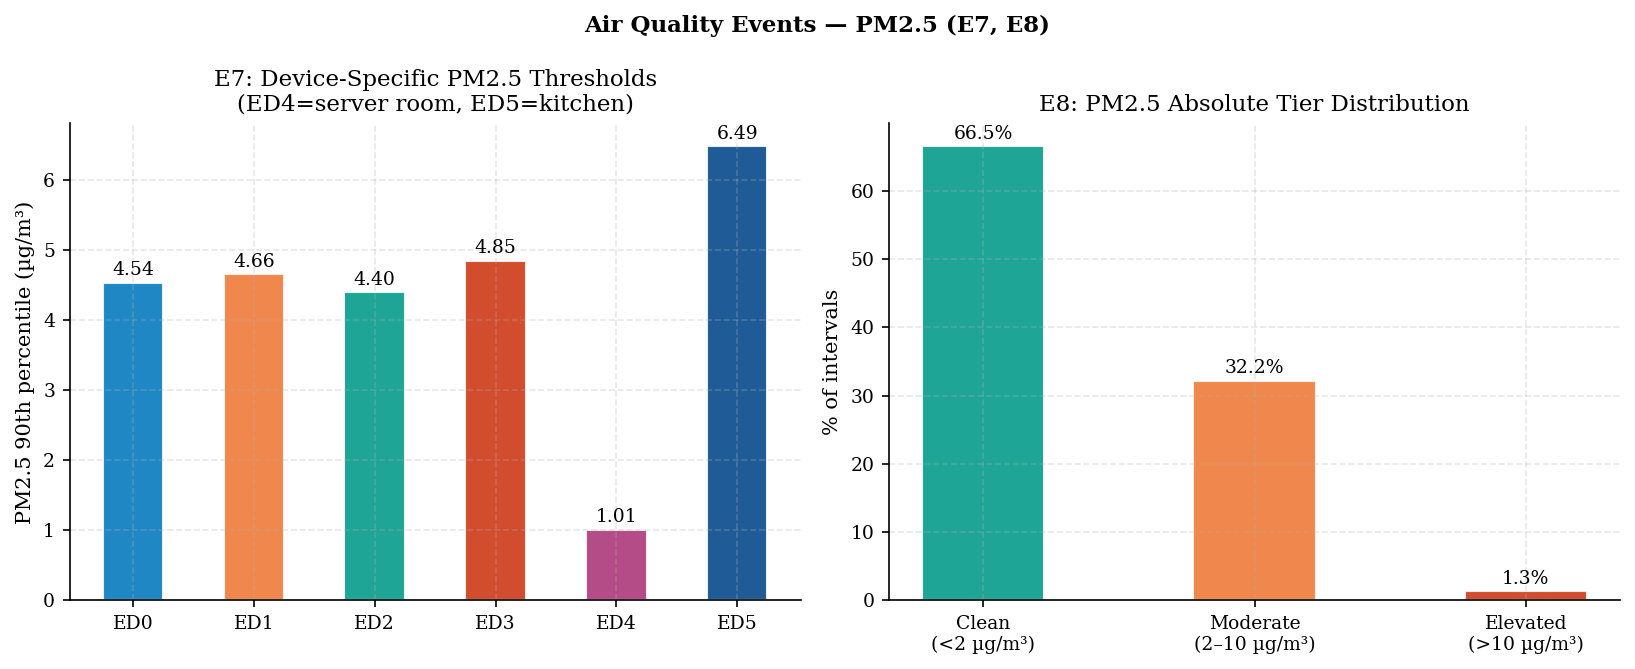

In [8]:
# Fig 02-C — PM2.5 Device Thresholds and Tier Distribution
DEVICES_L = sorted(df['device_id'].unique())
pm25_q90 = df.groupby('device_id')['pm25'].quantile(0.90)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(DEVICES_L, [pm25_q90[d] for d in DEVICES_L], color=DEVICE_COLORS[:len(DEVICES_L)],
             width=0.5, alpha=0.88, edgecolor='white')
for i,(dev,v) in enumerate(zip(DEVICES_L,[pm25_q90[d] for d in DEVICES_L])):
    axes[0].text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('PM2.5 90th percentile (\u00b5g/m\u00b3)')
axes[0].set_title('E7: Device-Specific PM2.5 Thresholds\n(ED4=server room, ED5=kitchen)')

pm_tiers=['clean','moderate','elevated']
pm_labs=['Clean\n(<2 \u00b5g/m\u00b3)','Moderate\n(2–10 \u00b5g/m\u00b3)','Elevated\n(>10 \u00b5g/m\u00b3)']
pm_pcts=[df['e8_pm25_tier'].eq(t).mean()*100 for t in pm_tiers]
bars=axes[1].bar(pm_labs,pm_pcts,color=[C['green'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,pm_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1].set_ylabel('% of intervals'); axes[1].set_title('E8: PM2.5 Absolute Tier Distribution')

fig.suptitle('Air Quality Events — PM2.5 (E7, E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_c_pm25_events')


## 4 · Atmospheric Events  *(§6.4)*

| Event | Definition |
|-------|-----------|
| E9 | Pressure tier: campaign quartiles — captures seasonal weather variation |
| E10 | Pressure drop: delta < −0.5 hPa per 60s — HVAC switch or door opening |
| E11 | Humidity tier: dry (<40%) / normal (40–55%) / humid (55–70%) / very_humid (>70%) |
| E12 | Temperature tier: campaign quartiles — HVAC set-point shifts seasonally |

Note: pressure values in the dataset are scaled (287–348 range) rather than true hPa.  
All six devices show identical scaling — relative variation is preserved and analysis is unaffected.

In [ ]:
# E9: pressure tier — quartile-based to capture seasonal variation
df['e9_pressure_tier'] = pd.qcut(
    df['pressure'], q=4,
    labels=['low', 'medium_low', 'medium_high', 'high'],
    duplicates='drop'
)

# E10: pressure drop — HVAC switch or door-opening transient
df['e10_pressure_drop'] = (
        df.groupby('device_id')['pressure'].diff() < -0.5
).astype(int)

# E11: humidity tier — absolute bands
df['e11_humidity_tier'] = pd.cut(
    df['humidity'],
    bins=[0, 40, 55, 70, 101],
    labels=['dry', 'normal', 'humid', 'very_humid']
)

# E12: temperature tier — quartile-based because HVAC set-point shifts across seasons
df['e12_temp_tier'] = pd.qcut(
    df['temperature'], q=4,
    labels=['cold', 'cool', 'warm', 'hot'],
    duplicates='drop'
)

print(f'Pressure range   : {df["pressure"].min():.1f} – {df["pressure"].max():.1f} (scaled)')
print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')
print(f'Temperature range: {df["temperature"].min():.1f} – {df["temperature"].max():.1f} °C')
print(f'Pressure drops   : {df["e10_pressure_drop"].sum():,} intervals')

  Saved: 02_d_atmospheric_distributions


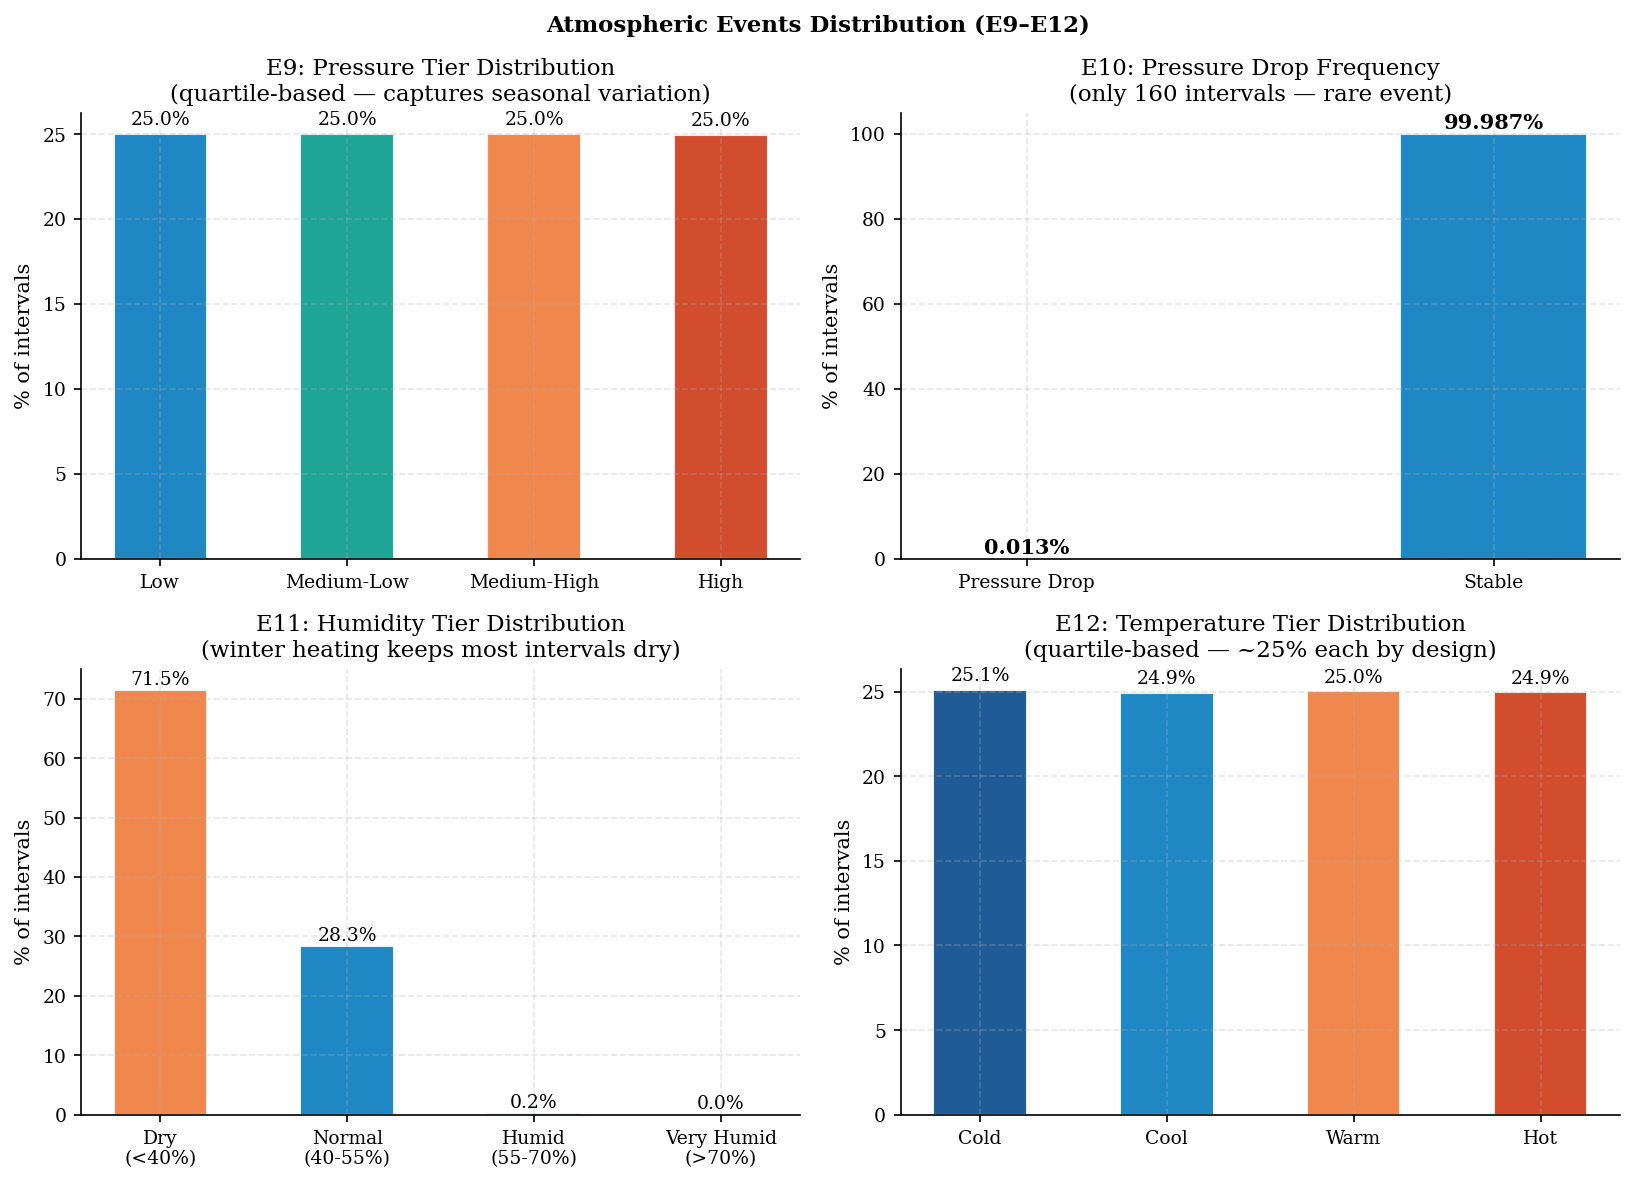

In [10]:
# Fig 02-D-atm — Atmospheric Event Distributions (E9-E12)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# E9: pressure tier
pt = ['low','medium_low','medium_high','high']
pt_labs = ['Low','Medium-Low','Medium-High','High']
pt_pcts = [df['e9_pressure_tier'].eq(t).mean()*100 for t in pt]
bars = axes[0,0].bar(pt_labs, pt_pcts, color=[C['blue'],C['green'],C['orange'],C['red']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pt_pcts):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[0,0].set_ylabel('% of intervals')
axes[0,0].set_title('E9: Pressure Tier Distribution\n(quartile-based — captures seasonal variation)')

# E10: pressure drop rate
drop_rate = df['e10_pressure_drop'].mean()*100
axes[0,1].bar(['Pressure Drop','Stable'],
               [drop_rate, 100-drop_rate],
               color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i, v in enumerate([drop_rate, 100-drop_rate]):
    axes[0,1].text(i, v+0.3, f'{v:.3f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,1].set_ylabel('% of intervals')
axes[0,1].set_title(f'E10: Pressure Drop Frequency\n(only {df["e10_pressure_drop"].sum()} intervals — rare event)')

# E11: humidity tier
ht = ['dry','normal','humid','very_humid']
ht_labs = ['Dry\n(<40%)','Normal\n(40-55%)','Humid\n(55-70%)','Very Humid\n(>70%)']
ht_pcts = [df['e11_humidity_tier'].eq(t).mean()*100 for t in ht]
bars = axes[1,0].bar(ht_labs, ht_pcts,
                      color=[C['orange'],C['blue'],C['green'],C['navy']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, ht_pcts):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[1,0].set_ylabel('% of intervals')
axes[1,0].set_title('E11: Humidity Tier Distribution\n(winter heating keeps most intervals dry)')

# E12: temperature tier
tt = ['cold','cool','warm','hot']
tt_labs = ['Cold','Cool','Warm','Hot']
tt_pcts = [df['e12_temp_tier'].eq(t).mean()*100 for t in tt]
bars = axes[1,1].bar(tt_labs, tt_pcts,
                      color=[C['navy'],C['blue'],C['orange'],C['red']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pcts):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[1,1].set_ylabel('% of intervals')
axes[1,1].set_title('E12: Temperature Tier Distribution\n(quartile-based — ~25% each by design)')

fig.suptitle('Atmospheric Events Distribution (E9–E12)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_d_atmospheric_distributions')


## 5 · Transmission Configuration Events  *(§6.5)*

SF directly controls Time-on-Air (ToA) — the duration a packet occupies the channel.  
Under LoRaWAN's ALOHA protocol, longer ToA = wider collision window.

ADR was disabled and SFs were manually rotated across the campaign.  
SF distribution is approximately equal (~25% each) — ensuring fair event comparison.

| SF | ToA (ms) | Collision window vs SF7 |
|----|---------|------------------------|
| 7 | 71.9 | baseline |
| 8 | 133.6 | 1.9× |
| 9 | 246.8 | 3.4× |
| 10 | 452.6 | 6.3× |

| Event | Definition |
|-------|-----------|
| E13 | SF categorical: 7 / 8 / 9 / 10 |
| E14 | SF tier: low_sf (7–8) / high_sf (9–10) |
| E15 | ToA class: short_toa / long_toa — collision risk expressed explicitly |

In [11]:
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6}  # ms at BW=125kHz, 26-byte payload

# E13: spreading factor — categorical
df['e13_sf'] = df['SF'].astype(int)

# E14: SF tier — binary split at the ToA doubling boundary (SF8→SF9)
df['e14_sf_tier'] = df['e13_sf'].apply(
    lambda s: 'low_sf' if s in (7, 8) else 'high_sf'
)

# E15: ToA class and numeric value — kept for continuous analysis in notebook 03
df['e15_toa_ms'] = df['e13_sf'].map(TOA_MS)
df['e15_toa_class'] = df['e14_sf_tier'].map({'low_sf': 'short_toa', 'high_sf': 'long_toa'})

print('SF distribution:')
print(df['e13_sf'].value_counts(normalize=True).mul(100).sort_index().round(1).astype(str).add('%').to_string())

SF distribution:
e13_sf
7     26.0%
8     25.8%
9     24.7%
10    23.4%


  Saved: 02_d_sf_distribution


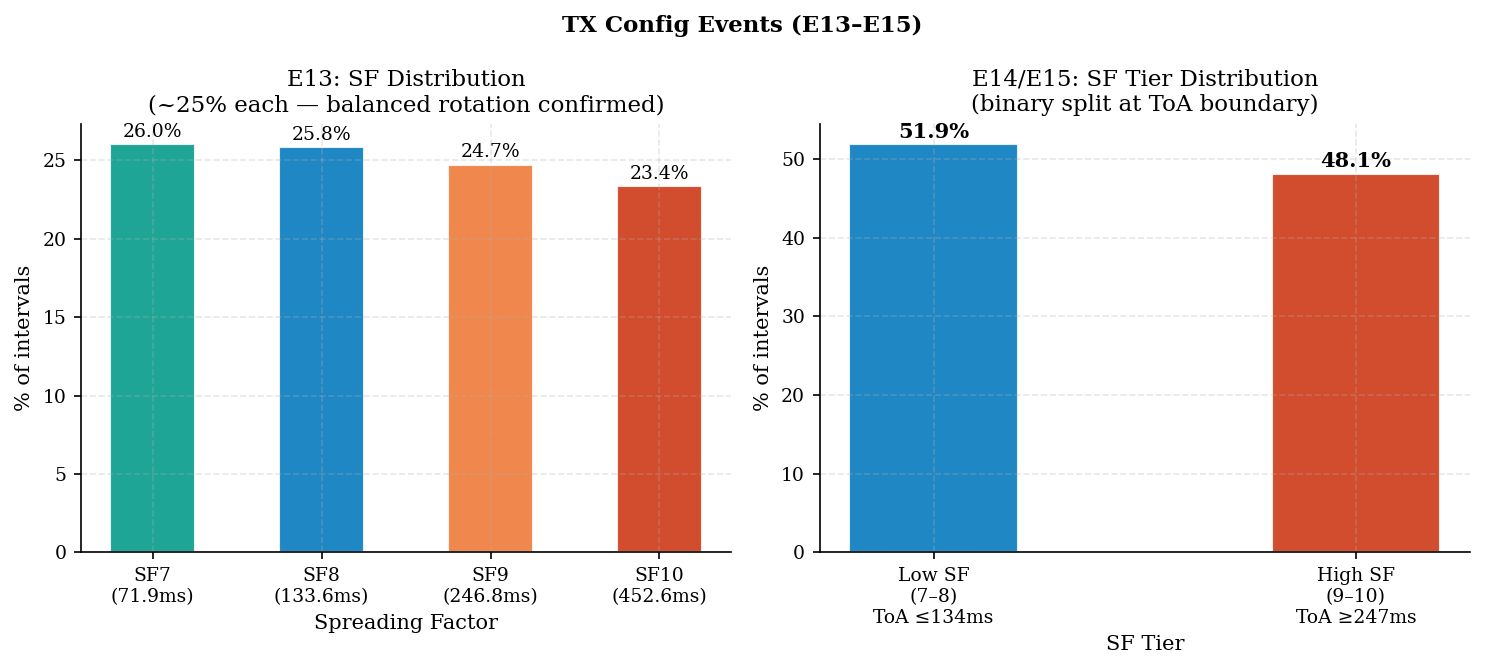

In [12]:
# Fig 02-E — SF Distribution (E13, E14, E15)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sfs=[7,8,9,10]
sf_xlabs=[f'SF{sf}\n({TOA_MS[sf]}ms)' for sf in sfs]
sf_pcts=[df['e13_sf'].eq(sf).mean()*100 for sf in sfs]
bars=axes[0].bar(sf_xlabs,sf_pcts,color=[C['green'],C['blue'],C['orange'],C['red']],
                  width=0.5,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,sf_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+0.2,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('Spreading Factor')
axes[0].set_title('E13: SF Distribution\n(~25% each — balanced rotation confirmed)')

st_pcts=[df['e14_sf_tier'].eq(t).mean()*100 for t in ['low_sf','high_sf']]
axes[1].bar(['Low SF\n(7–8)\nToA ≤134ms','High SF\n(9–10)\nToA ≥247ms'],
             st_pcts,color=[C['blue'],C['red']],width=0.4,alpha=0.88,edgecolor='white')
for i,v in enumerate(st_pcts):
    axes[1].text(i,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('SF Tier')
axes[1].set_title('E14/E15: SF Tier Distribution\n(binary split at ToA boundary)')

fig.suptitle('TX Config Events (E13–E15)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_e_sf_distribution')

## 6 · Burst Loss Event  *(§6.6)*

Classifies each interval by how many consecutive packets were lost before the received packet.  
Burst loss is qualitatively different from isolated loss — it creates contiguous data gaps  
that cannot be recovered by interpolation.

**B=3 threshold:** 3 consecutive losses = 3-minute gap — minimum that visibly disrupts  
slowly-varying environmental signals like CO₂ and temperature.

SF rotation artifacts are set to 0 before classification — they are deterministic transition  
losses already flagged by `is_sf_artifact` and not environmental bursts.

| Class | Condition | Interpretation |
|-------|-----------|---------------|
| no_loss | 0 | Clean reception |
| isolated | 1 | Single random collision |
| small_burst | 2–4 | Brief channel degradation |
| large_burst | 5+ | Sustained interference |

In [13]:
# E16: burst loss classification
# SF artifacts replaced with 0 — deterministic transition losses, not environmental bursts
df['e16_loss_type'] = pd.cut(
    df['mac_to_radio_loss'].where(~df['is_sf_artifact'], 0),
    bins=[-1, 0, 1, 4, 10_000_000],
    labels=['no_loss', 'isolated', 'small_burst', 'large_burst']
)

print('Loss type distribution:')
print(df['e16_loss_type'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())

Loss type distribution:
e16_loss_type
no_loss        98.2%
isolated        1.2%
small_burst     0.4%
large_burst     0.2%


  Saved: 02_e_burst_loss_distribution


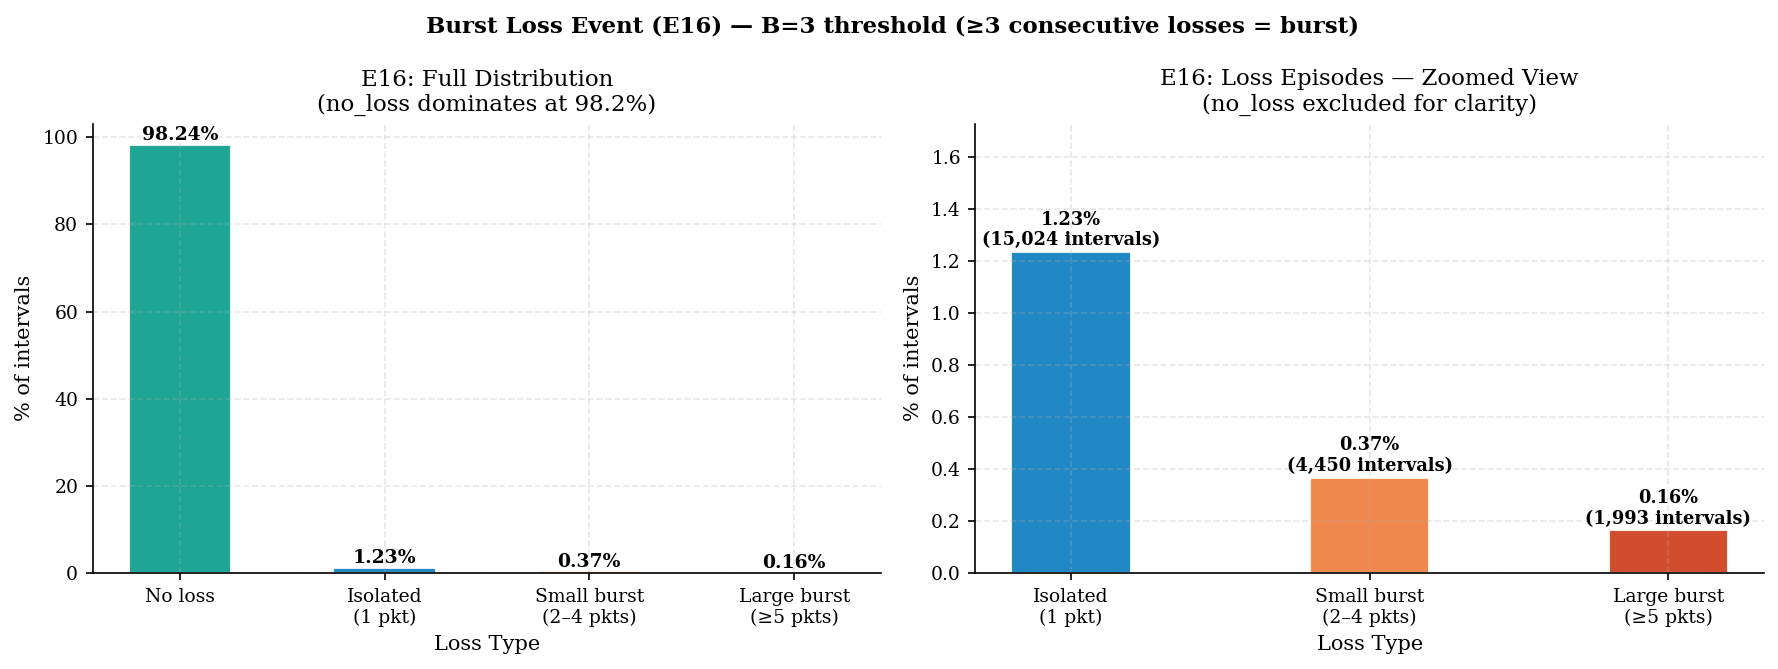

In [14]:
# Fig 02-F — Burst Loss Distribution (E16)
order  = ['no_loss','isolated','small_burst','large_burst']
olabs  = ['No loss','Isolated\n(1 pkt)','Small burst\n(2–4 pkts)','Large burst\n(≥5 pkts)']
o_pcts = [df['e16_loss_type'].eq(o).mean()*100 for o in order]
o_counts = [df['e16_loss_type'].eq(o).sum() for o in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: all four types
bars = axes[0].bar(olabs, o_pcts,
                    color=[C['green'],C['blue'],C['orange'],C['red']],
                    width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, o_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.1,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('Loss Type')
axes[0].set_title('E16: Full Distribution\n(no_loss dominates at 98.2%)')

# right: zoomed — loss-only types (no_loss excluded)
zoom_order  = ['isolated','small_burst','large_burst']
zoom_labs   = ['Isolated\n(1 pkt)','Small burst\n(2–4 pkts)','Large burst\n(≥5 pkts)']
zoom_pcts   = [df['e16_loss_type'].eq(o).mean()*100 for o in zoom_order]
zoom_counts = [df['e16_loss_type'].eq(o).sum() for o in zoom_order]

bars2 = axes[1].bar(zoom_labs, zoom_pcts,
                     color=[C['blue'],C['orange'],C['red']],
                     width=0.4, alpha=0.88, edgecolor='white')
for bar, v, cnt in zip(bars2, zoom_pcts, zoom_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.2f}%\n({cnt:,} intervals)', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('Loss Type')
axes[1].set_title('E16: Loss Episodes — Zoomed View\n(no_loss excluded for clarity)')
axes[1].set_ylim(0, max(zoom_pcts)*1.4)

fig.suptitle('Burst Loss Event (E16) — B=3 threshold (≥3 consecutive losses = burst)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_f_burst_loss_distribution')

## 7 · Signal Context Events  *(§6.7)*

RSSI and ESP are only available for received packets — never for lost ones.  
E17 and E18 use the signal quality of the packet received immediately before the loss interval  
as a proxy for channel state at the time of loss.

| Event | Definition |
|-------|-----------|
| E17 | RSSI tier: weak (<−90) / moderate (−90 to −70) / strong (>−70 dBm) |
| E18 | ESP tier: campaign tertile-based — ESP combines RSSI and SNR (§2.2.3) |

In [15]:
# E17: RSSI tier — thresholds reflect SF7-SF10 receiver sensitivity range (Table 2.2)
df['e17_rssi_tier'] = pd.cut(
    df['rssi'],
    bins=[-200, -90, -70, 0],
    labels=['weak', 'moderate', 'strong']
)

# E18: ESP tier — tertile-based, no obvious physical breakpoints in ESP distribution
df['e18_esp_tier'] = pd.qcut(
    df['esp'], q=3,
    labels=['low_esp', 'medium_esp', 'high_esp'],
    duplicates='drop'
)

print('RSSI tier distribution:')
print(df['e17_rssi_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(f'\nRSSI range: {df["rssi"].min():.0f} to {df["rssi"].max():.0f} dBm')
print(f'ESP  range: {df["esp"].min():.1f} to {df["esp"].max():.1f} dBm')

RSSI tier distribution:
e17_rssi_tier
strong      51.0%
moderate    28.9%
weak        20.1%

RSSI range: -128 to -29 dBm
ESP  range: -141.1 to -29.8 dBm


  Saved: fig_02_f_signal_context_distribution


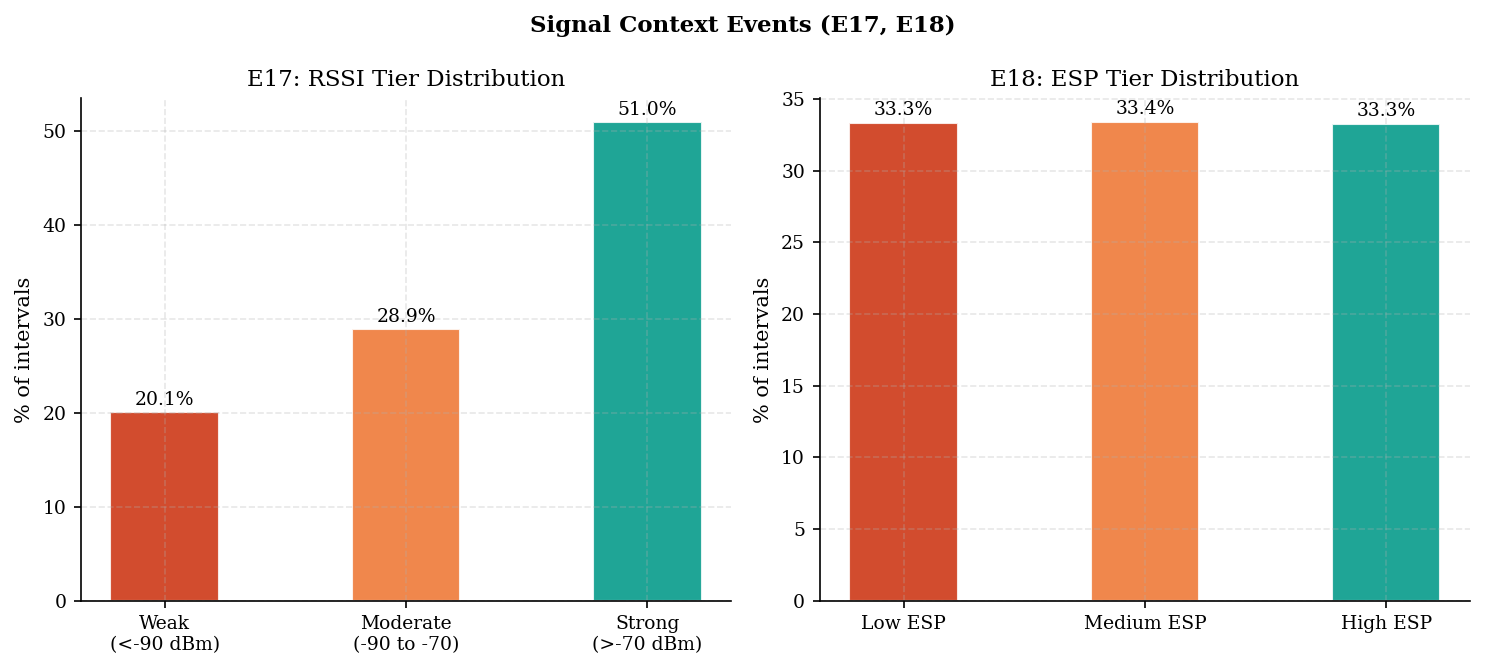

In [16]:
# Fig 02-G — Signal Context Events (E17, E18)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

rt=['weak','moderate','strong']
rt_labs=['Weak\n(<-90 dBm)','Moderate\n(-90 to -70)','Strong\n(>-70 dBm)']
rt_pcts=[df['e17_rssi_tier'].eq(t).mean()*100 for t in rt]
bars=axes[0].bar(rt_labs,rt_pcts,color=[C['red'],C['orange'],C['green']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,rt_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_title(f'E17: RSSI Tier Distribution')

et=['low_esp','medium_esp','high_esp']
et_labs=['Low ESP','Medium ESP','High ESP']
et_pcts=[df['e18_esp_tier'].eq(t).mean()*100 for t in et]
bars=axes[1].bar(et_labs,et_pcts,color=[C['red'],C['orange'],C['green']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,et_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1].set_ylabel('% of intervals'); axes[1].set_title('E18: ESP Tier Distribution')

fig.suptitle('Signal Context Events (E17, E18)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'fig_02_g_signal_context_distribution')


## 8 · Event Taxonomy  *(Table 6.1)*

In [17]:
event_taxonomy = [
    ('E1', 'Occupancy', 'e1_co2_tier', 'CO2 concentration tier'),
    ('E2', 'Occupancy', 'e2_co2_rising', 'CO2 rising > 20ppm/60s'),
    ('E3', 'Temporal', 'e3_is_weekday', 'Weekday vs weekend'),
    ('E4', 'Temporal', 'e4_time_of_day', 'Time of day band'),
    ('E5', 'Temporal', 'e5_office_hours', 'Office hours'),
    ('E6', 'Temporal', 'e6_season', 'Season'),
    ('E7', 'Air Quality', 'e7_pm25_spike', 'PM2.5 device-specific spike'),
    ('E8', 'Air Quality', 'e8_pm25_tier', 'PM2.5 absolute tier'),
    ('E9', 'Atmospheric', 'e9_pressure_tier', 'Pressure tier'),
    ('E10', 'Atmospheric', 'e10_pressure_drop', 'Pressure drop event'),
    ('E11', 'Atmospheric', 'e11_humidity_tier', 'Humidity tier'),
    ('E12', 'Atmospheric', 'e12_temp_tier', 'Temperature tier'),
    ('E13', 'TX Config', 'e13_sf', 'Spreading factor'),
    ('E14', 'TX Config', 'e14_sf_tier', 'SF tier (low/high)'),
    ('E15', 'TX Config', 'e15_toa_class', 'Time-on-Air class'),
    ('E16', 'Burst Loss', 'e16_loss_type', 'Loss episode type'),
    ('E17', 'Signal Context', 'e17_rssi_tier', 'RSSI tier'),
    ('E18', 'Signal Context', 'e18_esp_tier', 'ESP tier'),
]

print(f"{'ID':<5} {'Family':<16} {'Column':<22} {'Name':<30} {'Possible Values'}")
print('-' * 105)
for eid, family, col, name in event_taxonomy:
    dtype = df[col].dtype
    if col == 'e13_sf':
        coverage = f'values: {sorted(df[col].unique().tolist())}'
    elif str(dtype) in ['int64', 'bool']:
        coverage = f'{df[col].mean() * 100:.1f}% active'
    else:
        coverage = str(sorted([x for x in df[col].unique() if str(x) != 'nan']))
    print(f'{eid:<5} {family:<16} {col:<22} {name:<30} {coverage}')

ID    Family           Column                 Name                           Possible Values
---------------------------------------------------------------------------------------------------------
E1    Occupancy        e1_co2_tier            CO2 concentration tier         ['background', 'high', 'moderate']
E2    Occupancy        e2_co2_rising          CO2 rising > 20ppm/60s         0.3% active
E3    Temporal         e3_is_weekday          Weekday vs weekend             70.9% active
E4    Temporal         e4_time_of_day         Time of day band               ['evening', 'morning', 'night', 'peak']
E5    Temporal         e5_office_hours        Office hours                   29.2% active
E6    Temporal         e6_season              Season                         ['autumn', 'spring', 'winter']
E7    Air Quality      e7_pm25_spike          PM2.5 device-specific spike    10.0% active
E8    Air Quality      e8_pm25_tier           PM2.5 absolute tier            ['clean', 'elevated', 'moder

## 9 · Save

In [18]:
original_cols = [c for c in df.columns
                 if not (c.startswith('e') and '_' in c)
                 and c not in ['hour', 'dayofweek', 'month', 'exp_pl']]

event_cols_ordered = [
    'e1_co2_tier', 'e2_co2_rising', 'e3_is_weekday',
    'e4_time_of_day', 'e5_office_hours', 'e6_season',
    'e7_pm25_spike', 'e8_pm25_tier',
    'e9_pressure_tier', 'e10_pressure_drop', 'e11_humidity_tier', 'e12_temp_tier',
    'e13_sf', 'e14_sf_tier', 'e15_toa_ms', 'e15_toa_class',
    'e16_loss_type', 'e17_rssi_tier', 'e18_esp_tier'
]

df = df[[c for c in original_cols if c in df.columns] + event_cols_ordered]
df.to_csv(DATA_DIR / '2_events.csv', index=False)

print(f'Saved  : {DATA_DIR / "2_events.csv"}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)} total | 18 events + e15_toa_ms')

Saved  : ..\data\2_events.csv
Rows   : 1,217,313
Columns: 46 total | 18 events + e15_toa_ms
